<a href="https://colab.research.google.com/github/MuavizKhan/automobile-predictive-failure/blob/main/main_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score


In [17]:
# Load the dataset
dataset = pd.read_csv("/content/vehicle_failure_detection.csv")
dataset

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...,...,...
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0


In [18]:
# Drop unnecessary columns
dataset = dataset.drop(['UDI', 'Product ID'], axis=1)

In [19]:
dataset.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [20]:
dataset.shape

(10000, 7)

In [21]:
dataset.dtypes

,0
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Target,int64


In [22]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Type                     10000 non-null  object 
 1   Air temperature [K]      10000 non-null  float64
 2   Process temperature [K]  10000 non-null  float64
 3   Rotational speed [rpm]   10000 non-null  int64  
 4   Torque [Nm]              10000 non-null  float64
 5   Tool wear [min]          10000 non-null  int64  
 6   Target                   10000 non-null  int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 547.0+ KB


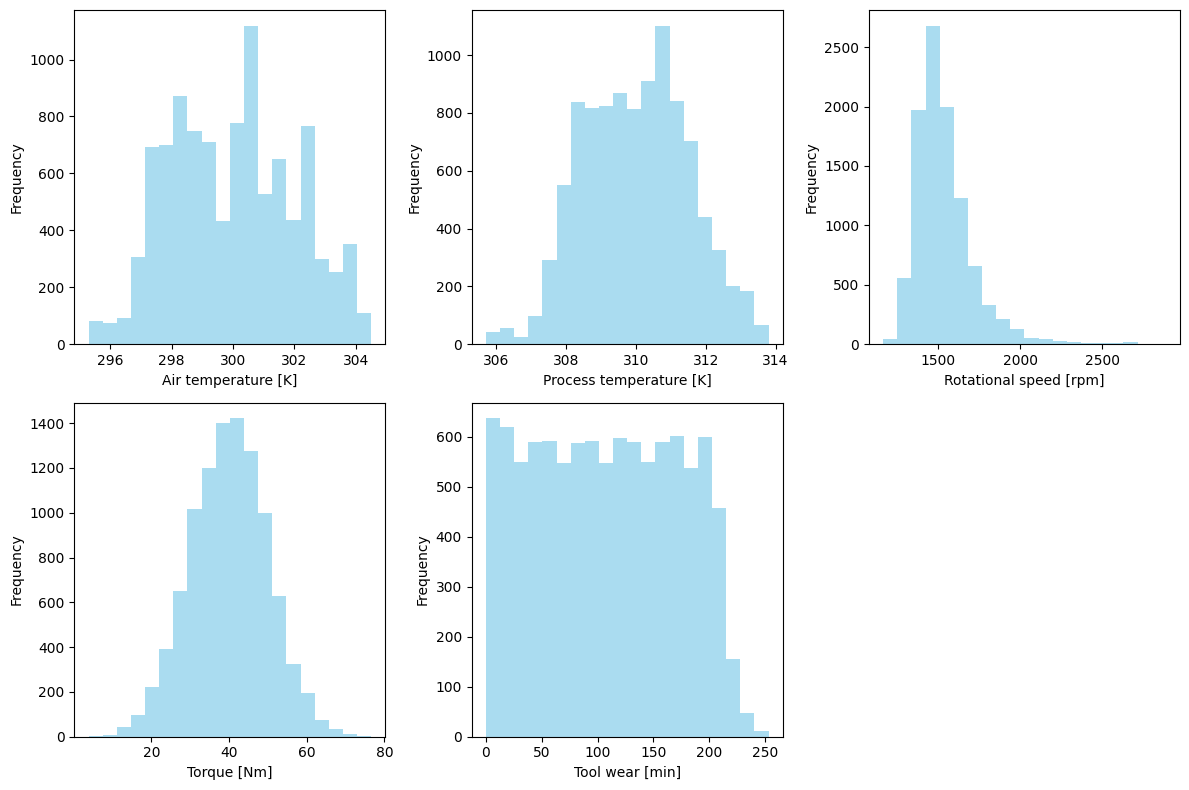

In [23]:
# Histograms for numerical features
plt.figure(figsize=(12, 8))
for i, feature in enumerate(['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'], start=1):
    plt.subplot(2, 3, i)
    plt.hist(dataset[feature], bins=20, color='skyblue', alpha=0.7)
    plt.xlabel(feature)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


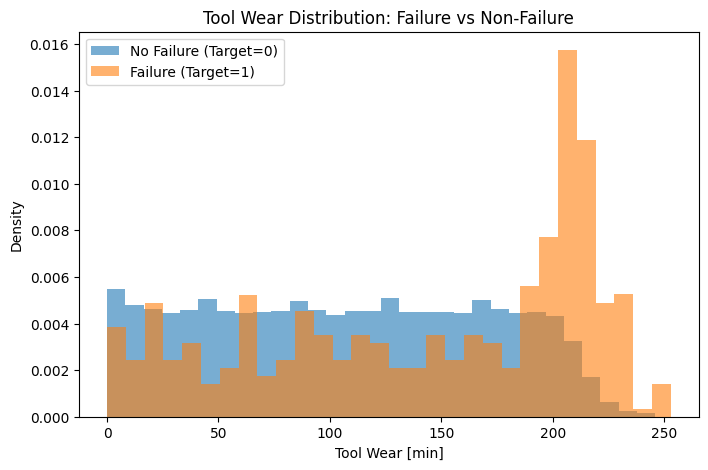

In [26]:
plt.figure(figsize=(8,5))

plt.hist(
    dataset[dataset["Target"] == 0]["Tool wear [min]"],
    bins=30,
    alpha=0.6,
    label="No Failure (Target=0)",
    density=True
)

plt.hist(
    dataset[dataset["Target"] == 1]["Tool wear [min]"],
    bins=30,
    alpha=0.6,
    label="Failure (Target=1)",
    density=True
)

plt.xlabel("Tool Wear [min]")
plt.ylabel("Density")
plt.title("Tool Wear Distribution: Failure vs Non-Failure")
plt.legend()
plt.show()


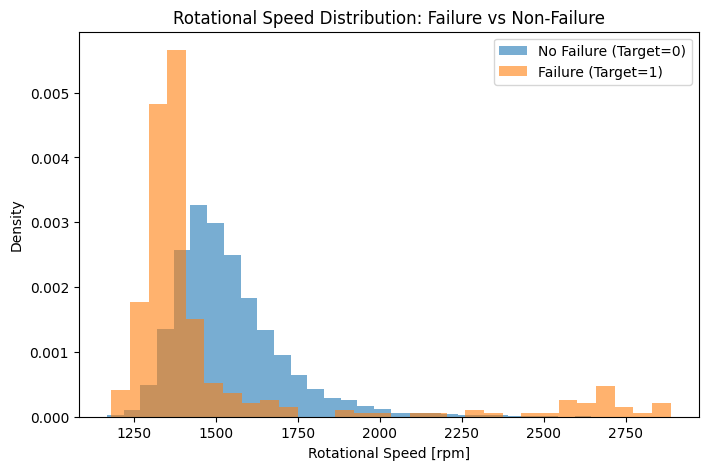

In [27]:
plt.figure(figsize=(8,5))

plt.hist(
    dataset[dataset["Target"] == 0]["Rotational speed [rpm]"],
    bins=30,
    alpha=0.6,
    label="No Failure (Target=0)",
    density=True
)

plt.hist(
    dataset[dataset["Target"] == 1]["Rotational speed [rpm]"],
    bins=30,
    alpha=0.6,
    label="Failure (Target=1)",
    density=True
)

plt.xlabel("Rotational Speed [rpm]")
plt.ylabel("Density")
plt.title("Rotational Speed Distribution: Failure vs Non-Failure")
plt.legend()
plt.show()


In [29]:
# Feature Engineering: Interaction Features

dataset["speed_wear"] = (
    dataset["Rotational speed [rpm]"] * dataset["Tool wear [min]"]
)

dataset["speed_torque"] = (
    dataset["Rotational speed [rpm]"] * dataset["Torque [Nm]"]
)

dataset[["speed_wear", "speed_torque"]].head()


,speed_wear,speed_torque
0,0,66382.8
1,4224,65190.4
2,7490,74001.2
3,10031,56603.5
4,12672,56320.0


In [30]:
dataset[["speed_wear", "speed_torque"]].describe()


,speed_wear,speed_torque
count,10000.000000,10000.000000
mean,166114.964400,59967.147040
std,100560.463537,10193.093881
min,0.000000,10966.800000
25%,80914.250000,53105.400000
50%,163332.000000,59883.900000
75%,247809.250000,66873.750000
max,607375.000000,99980.400000


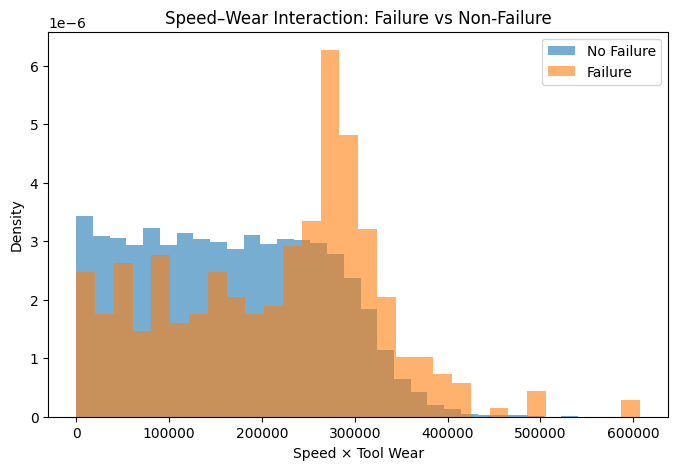

In [31]:
plt.figure(figsize=(8,5))

plt.hist(
    dataset[dataset["Target"] == 0]["speed_wear"],
    bins=30,
    alpha=0.6,
    density=True,
    label="No Failure"
)

plt.hist(
    dataset[dataset["Target"] == 1]["speed_wear"],
    bins=30,
    alpha=0.6,
    density=True,
    label="Failure"
)

plt.xlabel("Speed × Tool Wear")
plt.ylabel("Density")
plt.title("Speed–Wear Interaction: Failure vs Non-Failure")
plt.legend()
plt.show()


In [33]:
dataset

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,speed_wear,speed_torque
0,M,298.1,308.6,1551,42.8,0,0,0,66382.8
1,L,298.2,308.7,1408,46.3,3,0,4224,65190.4
2,L,298.1,308.5,1498,49.4,5,0,7490,74001.2
3,L,298.2,308.6,1433,39.5,7,0,10031,56603.5
4,L,298.2,308.7,1408,40.0,9,0,12672,56320.0
...,...,...,...,...,...,...,...,...,...
9995,M,298.8,308.4,1604,29.5,14,0,22456,47318.0
9996,H,298.9,308.4,1632,31.8,17,0,27744,51897.6
9997,M,299.0,308.6,1645,33.4,22,0,36190,54943.0
9998,H,299.0,308.7,1408,48.5,25,0,35200,68288.0


In [1]:
# Boxplots for numerical features by target variable
plt.figure(figsize=(12, 8))
for i, feature in enumerate(['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'], start=1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Target', y=feature, data=dataset)
    plt.xlabel('Target')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()


NameError: name 'plt' is not defined

In [ ]:

# Define the numerical features (excluding the target variable)
numerical_features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

# Function to handle outliers using IQR method
def handle_outliers(data, features):
    for feature in features:
        # Calculate the IQR
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1

        # Define the boundaries for outliers
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Replace outliers with NaN
        data.loc[(data[feature] < lower_bound) | (data[feature] > upper_bound), feature] = np.nan

    return data

# Handle outliers
dataset_cleaned = handle_outliers(dataset.copy(), numerical_features)

# Drop rows with NaN values (outliers)
dataset_cleaned.dropna(inplace=True)

# Print the cleaned dataset
dataset_cleaned.head()

In [ ]:
#After outliers are handled
# Boxplots for numerical features by target variable
plt.figure(figsize=(12, 8))
for i, feature in enumerate(['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'], start=1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='Target', y=feature, data=dataset_cleaned)
    plt.xlabel('Target')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

In [ ]:
# Convert categorical variables to numerical using label encoding
label_encoder = LabelEncoder()
for column in dataset.select_dtypes(include=['object']):
    dataset[column] = label_encoder.fit_transform(dataset[column])

In [ ]:
# Split dataset into features (X) and target variable (y)
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

In [ ]:
y.value_counts()

In [ ]:
# Balance the dataset using SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

In [ ]:
y_balanced.value_counts()

In [ ]:
X_balanced.describe().T

In [ ]:
X_balanced.info()

In [ ]:
numerical_columns = X_balanced.select_dtypes(include=['int64', 'float64']).columns
numerical_dataset = X_balanced[numerical_columns]

# Compute the correlation matrix
corr_matrix = numerical_dataset.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Correlation Matrix')
plt.show()

In [ ]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.3, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train.info()

In [ ]:
X_train

In [ ]:
X_test.info()

In [ ]:
# Create empty lists to store performance metrics
performance_metrics = []

In [ ]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(),
    'K Nearest Neighbors': KNeighborsClassifier(),
    'Support Vector Classifier': SVC(),
    'Random Forest': RandomForestClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'Artificial Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, activation='relu', solver='adam', random_state=42)
}

In [ ]:
# Train and evaluate each model
for name, model in models.items():
    # Train model
    model.fit(X_train_scaled, y_train)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Calculate performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Store performance metrics
    performance_metrics.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Confusion Matrix': conf_matrix
    })

In [ ]:
# Convert performance metrics to DataFrame
performance_df = pd.DataFrame(performance_metrics)
performance_df

In [ ]:
# Iterate through each model's confusion matrix
for index, row in performance_df.iterrows():
    model_name = row.name  # Use index as model name
    conf_matrix = row['Confusion Matrix']

    # Plot confusion matrix as heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='g')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()


In [ ]:
# Set the model names as the index for easier plotting
performance_df.set_index('Model', inplace=True)

# Plot performance metrics for each model
performance_df.plot(kind='bar', figsize=(10, 6))
plt.title('Performance Metrics by Model')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(title='Metric')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

print("\nStarting hyperparameter tuning with RandomizedSearchCV...")

# Parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Random Forest Classifier
rf = RandomForestClassifier(random_state=42)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,             # reduce to make it faster
    cv=3,
    verbose=2,             # keeps logs short but clear
    random_state=42,
    n_jobs=-1,
    scoring='f1',
    return_train_score=True
)

# Fit
random_search.fit(X_train_scaled, y_train)

# Convert results into DataFrame
results = pd.DataFrame(random_search.cv_results_)

# Print each iteration result
for i in range(len(results)):
    print(f"\nIteration {i+1}:")
    print("Params:", results.loc[i, "params"])
    print("Mean Test Score:", results.loc[i, "mean_test_score"])
    print("Std Test Score:", results.loc[i, "std_test_score"])
    print("Rank:", results.loc[i, "rank_test_score"])

print("\nBest parameters found:", random_search.best_params_)
best_rf = random_search.best_estimator_
print("Hyperparameter tuning complete.")


In [ ]:
print("\nEvaluating the fine-tuned model...")
y_pred = best_rf.predict(X_test_scaled)

# Print performance metrics
print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")

In [ ]:
print("\nVisualizing feature importances...")
# Get feature importances from the best model
importances = best_rf.feature_importances_
feature_names = X.columns

# Create a DataFrame for easy plotting
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Plotting the results
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_df)
plt.title('Feature Importance from Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()